# Imports

In [ ]:
# Downlaod files, handling files and setup
import gdown
import tarfile
import urllib.request
import zipfile
import os
import sys
import subprocess
from google.colab import drive
from pathlib import Path
from typing import List, Dict


# Data Visualization
import random
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import re

# ML pipeline
import numpy as np
import torch
from sklearn.metrics import average_precision_score, accuracy_score
from torch.utils.data import DataLoader


# Globals

In [ ]:
INPUT_DECOMPRESSED_IMAGES_BASE_PATH = os.path.join("input", "decompressed-dataset") # where input datasets are stored
INPUT_DATASET_BASE_PATH = os.path.join("input", "cnn-detection-dataset")

CNN_DETECTOR_PATH = os.path.join("detectors", "cnn-detector")
TOOLKIT_PATH = Path.cwd() / CNN_DETECTOR_PATH / "CNNDETECTOR_SUITE"

UNIVFD_DETECTOR_PATH = os.path.join("detectors", "univfd")
UNIVFD_SUITE_PATH = Path.cwd() / UNIVFD_DETECTOR_PATH / "UNIVFD_SUITE"
UNIVFD_WEIGHTS = UNIVFD_SUITE_PATH / "pretrained_weights" / "fc_weights.pth"

DECOMPRESSED_IMG_BASE_PATH = os.path.join("input", "decompressed-dataset", "compressed_images")
FULL_DS_PATH = os.path.join("input")
BPP_LEVELS = ("bpp12", "bpp50", "bpp100")

DEBUG = 1


KAGGLE_DATASET_PATH = "/kaggle/input/datasets/ricb03/cnn-detection-dataset-backup"
USING_KAGGLE = os.path.exists(KAGGLE_DATASET_PATH)
if USING_KAGGLE:
    # If on Kaggle, dataset is ready without explicit download
    INPUT_DATASET_BASE_PATH = KAGGLE_DATASET_PATH
    print(f"Esecuzione su Kaggle. Dataset rilevato in: {INPUT_DATASET_BASE_PATH}")


RESULTS_SAVE_DIR = ""

# Persistenza cross-sessione: su Drive gestita programmaticamente, su Kaggle si usa il tastino in alto a dx SAVE VERSION
if USING_KAGGLE:
    # CWD: kaggle/working
    RESULTS_SAVE_DIR = Path("ALL_Detection_Results") # relative; thus absolute path is kaggle/working/ALL_Detection_Results
else:
    drive.mount('/content/drive', force_remount=False)
    RESULTS_SAVE_DIR = Path("/content/drive/MyDrive/ALL_Detection_Results")

RESULTS_SAVE_DIR.mkdir(parents=True, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Utils

In [ ]:
def set_seeds(seed=123):
  np.random.seed(seed)
  random.seed(seed)
  torch.manual_seed(seed)

set_seeds()

# Data

## Resourse Download
All download are based on Google Drive in order to avoid time delay due to library or API limits.

In [ ]:
def download_CNNDetector_dataset():
  if USING_KAGGLE:
      print("Running on Kaggle")
      return

  def hf_fallback():
    url = "https://huggingface.co/datasets/sywang/CNNDetection/resolve/main/CNN_synth_testset.zip"
    zip_name = "CNN_synth_testset.zip"
    if not os.path.isdir(INPUT_DATASET_BASE_PATH):
        print("Downloading dataset from huggingface...")
        urllib.request.urlretrieve(url, zip_name)
        print("Extracting files...")
        with zipfile.ZipFile(zip_name, "r") as zip_ref:
            zip_ref.extractall(INPUT_DATASET_BASE_PATH)
        os.remove(zip_name)
        print("Dataset successfully extracted.")
    else:
        print("Dataset already found locally, skipping download.")

  ID = '12EVf1YYd58HHcFQIxPVXJ9mRU6dacyEq'  # dataset senza whichfaceisreal e senza seeingdark
  gdrive_url = f'https://drive.google.com/uc?id={ID}&export=download&confirm=t'
  zip_name = "cnn-detection-dataset_backup.zip"
  print("Extracting files...")
  if not os.path.isdir(INPUT_DATASET_BASE_PATH):
    print("Downloading dataset from Google Drive...")
    try:
      gdown.download(gdrive_url, zip_name, quiet=False)
      print("Extracting files...")
      with zipfile.ZipFile(zip_name, "r") as zip_ref:
        zip_ref.extractall(INPUT_DATASET_BASE_PATH)
        os.remove(zip_name)
        print("Dataset successfully extracted.")
    except Exception as e:
      print(f"Error during download: {e}")
      print(f"Downloading from Google Drive failed, fallback on huggingface download...")
      hf_fallback()
  else:
    print("CNNDETECTOR dataset already found locally, skipping download.")



def download_decompressed_images():
  ID = '1cKj7H9FX-3f_OcSCSJvpM0eUs3FIGjlA'  # to "pilot_dataset.tar.gz"
  #ID = '1myfOAsO-SP2tEPWVfREdXoT_iRWga1Lm' # to old version of "dataset_proj_cv.tar.gz" (pre bug spotted)
  gdrive_url = f'https://drive.google.com/uc?id={ID}&export=download&confirm=t'
  gdrive_tar = "dataset_proj_cv.tar.gz"

  if not os.path.isdir(INPUT_DECOMPRESSED_IMAGES_BASE_PATH):
    print("Downloading dataset from Google Drive...")
    os.makedirs("input", exist_ok=True)
    gdown.download(gdrive_url, gdrive_tar, quiet=False)

    print("Extracting files...")
    with tarfile.open(gdrive_tar, "r:gz") as tar_ref:
      tar_ref.extractall(INPUT_DECOMPRESSED_IMAGES_BASE_PATH)

      os.remove(gdrive_tar)
      print("Files successfully extracted.")
  else:
    print("Dataset already found locally, skipping download.")



def download_CNNDetector_detection_suite(install_req=True):
  ID = '1tQr4tX7B-lPqEhTwAfBPF8DLObM1enit'  # CNNDETECTOR_SUITE-zippato.zip
  gdrive_url = f'https://drive.google.com/uc?id={ID}&export=download&confirm=t'
  zip_name = "CNNDETECTOR_SUITE-zippato.zip"
  print("Extracting files...")
  if not os.path.isdir(CNN_DETECTOR_PATH):
    print("Downloading CNNDETECTOR from Google Drive...")
    os.makedirs("detectors", exist_ok=True)
    gdown.download(gdrive_url, zip_name, quiet=False)
    print("Extracting files...")
    with zipfile.ZipFile(zip_name, "r") as zip_ref:
      zip_ref.extractall(CNN_DETECTOR_PATH)
      os.remove(zip_name)
      print("CNNDETECTOR available.")
  else:
    print("CNNDETECTOR already found locally, skipping download.")
  if install_req:
    result = subprocess.run(["pip", "install", "-r", f"{CNN_DETECTOR_PATH}/CNNDETECTOR_SUITE/requirements.txt"], capture_output=True)

    if result.returncode != 0:
        print("❌ Error during installation of requirements.")
        print(result.stderr) # Contiene il testo dell'errore di pip
        print(result.stdout)
    else:
      print("✅ Requirements installed or already satisfied.")



def download_UnivFD_suite(install_req=True):
    ID = '14Lx_rMqf1WrAY-f8IGe0oZ_Wfxa44MQy'
    gdrive_url = f'https://drive.google.com/uc?id={ID}&export=download&confirm=t'
    zip_name = "UNIVFD_SUITE.zip"

    if not os.path.isdir(UNIVFD_DETECTOR_PATH):
        print("Downloading UnivFD suite from Google Drive...")
        os.makedirs("detectors", exist_ok=True)
        gdown.download(gdrive_url, zip_name, quiet=False)
        print("Extracting files...")
        with zipfile.ZipFile(zip_name, "r") as zip_ref:
            zip_ref.extractall(UNIVFD_DETECTOR_PATH)
        os.remove(zip_name)
        print("✅ UnivFD suite available.")
    else:
        print("UnivFD suite already found locally, skipping download.")

    if install_req:
        result = subprocess.run(
            ["pip", "install", "scikit-learn", "tqdm", "ftfy", "regex"],
            capture_output=True
        )
        if result.returncode == 0:
            print("✅ UnivFD requirements installed.")
        else:
            print("❌ Error:", result.stderr.decode())


In [ ]:
download_CNNDetector_dataset()

Extracting files...
CNNDETECTOR dataset already found locally, skipping download.


In [ ]:
download_decompressed_images()

Dataset already found locally, skipping download.


In [ ]:
download_CNNDetector_detection_suite(install_req=True)

Extracting files...
CNNDETECTOR already found locally, skipping download.
✅ Requirements installed or already satisfied.


In [ ]:
download_UnivFD_suite()

UnivFD suite already found locally, skipping download.
✅ UnivFD requirements installed.


## Visual inspection


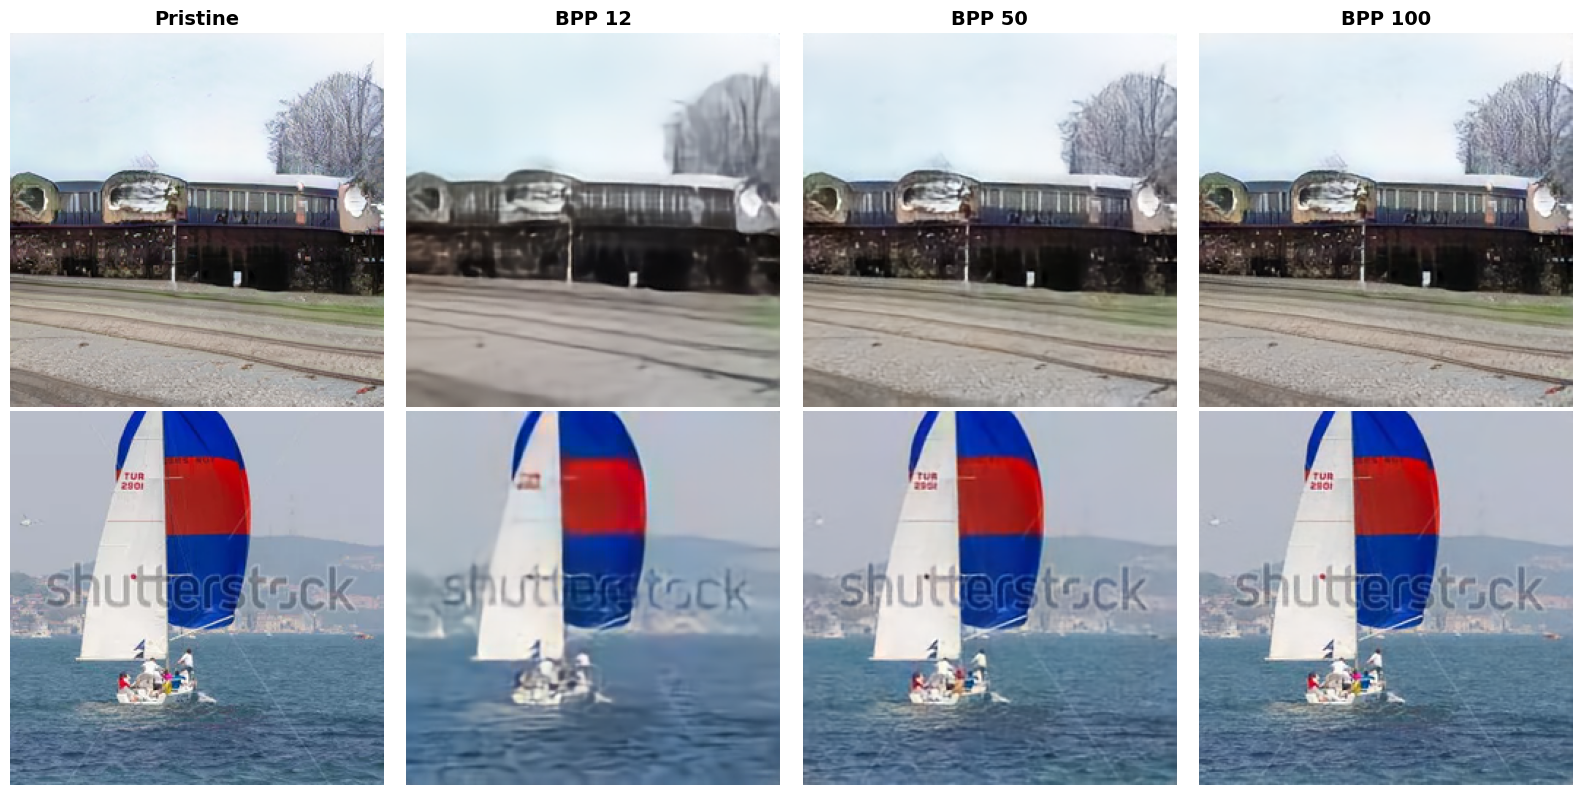

In [ ]:
def show_visual_comparison(samples:int=8):
  if samples < 2:
      print("At least 2 rows!")
      samples = 2

  # Paths
  pristine_base = Path(INPUT_DATASET_BASE_PATH)
  compressed_base = Path(DECOMPRESSED_IMG_BASE_PATH)

  # Get all images from bpp12 to use as a reference for finding matches
  ref_images = list((compressed_base / 'bpp12').rglob('*.png')) # extension-proof
  selected_refs = random.choices(ref_images, k=samples)

  # Grid : samples x 4
  fig, axes = plt.subplots(samples, 4, figsize=(16, 4 * samples))
  columns = ['Pristine', 'BPP 12', 'BPP 50', 'BPP 100']

  for i, ref_path in enumerate(selected_refs):
      # Relative path from the bpp12 folder to get the sub-structure
      rel_path = ref_path.relative_to(compressed_base / 'bpp12')
      # Prinstine/Main dataset and compressed one have the same structure
      pristine_path = pristine_base / rel_path
      # Row path are paths of the same img in diffent fashion: [pristine] + [1 for each BPP level]
      row_paths = [pristine_path] + [compressed_base / b / rel_path for b in BPP_LEVELS]

      """
      Path meaning:
      (fixed) compressed_base : input/decompressed-dataset/compressed_images
      (fixed) pristine_base : input/cnn-detection-dataset
      ref_path : input/decompressed-dataset/compressed_images/bpp12/progan/train/1_fake/03294.png
      rel_path : progan/train/1_fake/03294.png
      pristine_path : input/cnn-detection-dataset/progan/train/1_fake/03294.png
      """

      for j, img_path in enumerate(row_paths):
          ax = axes[i, j]
          if img_path.exists():
              img = Image.open(img_path)
              ax.imshow(img)
              if i == 0:
                  ax.set_title(columns[j], fontsize=14, fontweight='bold')
              # Label with relative path to confirm matching
              if j == 0:
                  ax.set_ylabel(f"Sample {i+1}", fontsize=12)
          else:
              print("Issue with path:", img_path)
              ax.text(0.5, 0.5, "Not Found", ha='center')
          ax.axis('off')

  plt.tight_layout()
  plt.show()

show_visual_comparison(samples = 2)

## Evaluation of Detectors
- CNNDetector model variant 0.5 (rate of JPEG compression)
- CNNDetector model variant 0.1
- Universal fake detector

### CNNDetector

In [ ]:
def get_id_from_path_and_detector(model_pth:str, detector:str):
    return "ID" + model_pth + detector

In [ ]:
# Load current results: checks on this information are used for persistency
try:
    current_global_df = pd.read_csv(Path(RESULTS_SAVE_DIR) / 'detSplit_modSplit_bppSplit_metricsSplit.csv')
    CURRENT_IDS = current_global_df["ID_Path"].tolist()
    display(current_global_df)
    print(len(CURRENT_IDS))
except: # empty file or non-existing file == first execution
    CURRENT_IDS = []

,detector,bpp,model,acc,ap,acc_real,acc_fake,ID_Path
0,weights/blur_jpg_prob0.5.pth,100,gaugan,88.00,99.45000,100.00,76.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
1,weights/blur_jpg_prob0.5.pth,100,imle,93.75,99.81000,100.00,87.5,IDweights/blur_jpg_prob0.5.pthinput/decompress...
2,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
3,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
4,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
5,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
6,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
7,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
8,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
9,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...


33


In [ ]:
detector_pth_to_test = ["weights/blur_jpg_prob0.5.pth", "weights/blur_jpg_prob0.1.pth"] # variants of CNNDetector
cnn_compression_results = {detector: {} for detector in detector_pth_to_test} # dictionary of results for CNNDetector in both variants

verbose=1
# GIRI_DEBUG = 10 ### solo per controllo #TODO: rimuovere assieme a idx nel ciclo


def get_dataset_paths():
  """ Search for dataset to run the detectors on. """
  DATASET_TO_CHECK = []
  if not os.path.exists(DECOMPRESSED_IMG_BASE_PATH):
    print("❌ Errore: dataset compresso non trovato.")
    return

  for root, dirs, files in os.walk(DECOMPRESSED_IMG_BASE_PATH):
    dirs.sort()
    files.sort()
    for dir in dirs:
      if os.path.exists(os.path.join(root,dir,"0_real")) and os.path.exists(os.path.join(root,dir,"1_fake")):
        DATASET_TO_CHECK.append(os.path.join(root,dir))
  return sorted(DATASET_TO_CHECK)

def test_detector_on_compressed(model_pth): # costruita su misura della struttura bppNUM/

  # Search for dataset to run the detector on
  DATASET_TO_CHECK = get_dataset_paths()

  for idx, d in enumerate(DATASET_TO_CHECK):
    # NO EXTRA WORK
    if get_id_from_path_and_detector(model_pth, d) in CURRENT_IDS:
        print(f"Skipping combination {(model_pth, d)}")
        continue

    # Search 'bpp'
    res = re.search(r"\d+", d)
    bpp=int(res.group())

    # Search 'model' name
    s = d.split("/")
    model = s[s.index(f"bpp{bpp}") + 1]

    ### Building the data structure
    if bpp not in cnn_compression_results[model_pth]:
      cnn_compression_results[model_pth][bpp] = {}
    if model not in cnn_compression_results[model_pth][bpp]:
      cnn_compression_results[model_pth][bpp][model] = {
        "Acc": [],
        "AP": [],
        "Acc_real": [],
        "Acc_fake": [],
        "ID_Path": [] # 'detector + path' per la persistenza
      }

    out=subprocess.run(f"python {TOOLKIT_PATH}/demo_dir.py -d {d} -m {TOOLKIT_PATH}/{model_pth}",capture_output=True,shell=True)
    str_out=str(out.stdout)
    index = str_out.find("AP")
    str_out=str_out[index:-3]
    res = str_out.split(",")
    res[0]=" "+res[0]

    if verbose:
      print("dataset:",d)
      print("bpp:",bpp)
      print("model:",model)

    for r in res:
      match = re.search(r"\d+\.\d+", r)
      if match:
        numerical_value = float(match.group())
        # Collect data
        if "Acc" in r and "real" not in r and "fake" not in r:
          cnn_compression_results[model_pth][bpp][model]["Acc"].append(numerical_value)
        elif "AP" in r:
          cnn_compression_results[model_pth][bpp][model]["AP"].append(numerical_value)
        elif "Acc (real)" in r:
          cnn_compression_results[model_pth][bpp][model]["Acc_real"].append(numerical_value)
        elif "Acc (fake)" in r:
            cnn_compression_results[model_pth][bpp][model]["Acc_fake"].append(numerical_value)
      if verbose:
        print(r)

    new_id = get_id_from_path_and_detector(model_pth, d)
    cnn_compression_results[model_pth][bpp][model]["ID_Path"].append(new_id)
    CURRENT_IDS.append(new_id)

    if verbose:
      print("-"*50)

    # if idx == GIRI_DEBUG: break

In [ ]:
# Run
for det in detector_pth_to_test:
    test_detector_on_compressed(model_pth=det)

Skipping combination ('weights/blur_jpg_prob0.5.pth', 'input/decompressed-dataset/compressed_images/bpp100/gaugan')
Skipping combination ('weights/blur_jpg_prob0.5.pth', 'input/decompressed-dataset/compressed_images/bpp100/imle')
Skipping combination ('weights/blur_jpg_prob0.5.pth', 'input/decompressed-dataset/compressed_images/bpp100/progan/airplane')
Skipping combination ('weights/blur_jpg_prob0.5.pth', 'input/decompressed-dataset/compressed_images/bpp100/progan/bicycle')
Skipping combination ('weights/blur_jpg_prob0.5.pth', 'input/decompressed-dataset/compressed_images/bpp100/progan/bird')
Skipping combination ('weights/blur_jpg_prob0.5.pth', 'input/decompressed-dataset/compressed_images/bpp100/progan/boat')
Skipping combination ('weights/blur_jpg_prob0.5.pth', 'input/decompressed-dataset/compressed_images/bpp100/progan/bottle')
Skipping combination ('weights/blur_jpg_prob0.5.pth', 'input/decompressed-dataset/compressed_images/bpp100/progan/bus')
Skipping combination ('weights/blur_

In [ ]:
cnn_compression_results # ispezione visiva

{'weights/blur_jpg_prob0.5.pth': {100: {'progan': {'Acc': [100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0],
    'AP': [100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0],
    'Acc_real': [100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0],
    'Acc_fake': [100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0],
    'ID_Path': ['IDweights/blur_jpg_prob0.5.pthinput/decompressed-dataset/compressed_images/bpp100/progan/cow',
     'IDweights/blur_jpg_prob0.5.pthinput/decompressed-dataset/compressed_images/bpp100/progan/diningtable',
     'IDweights/blur_jpg_prob0.5.pthinput/decompressed-dataset/compressed_images/bpp100/progan/dog',
     'IDweights/blur_jpg_prob0.5.pthinput/decompressed-dataset

In [ ]:
def get_flat_rows(compression_results: dict) -> pd.DataFrame:
    flat_rows = []
    for detector, bpps in compression_results.items():
        for bpp, models in bpps.items():
            for model, metrics in models.items():
                acc_list = metrics["Acc"]
                ap_list = metrics["AP"]
                acc_real_list = metrics["Acc_real"]
                ap_real_list = metrics["Acc_fake"]
                identifier_list = metrics["ID_Path"]

                # The 4 lists are updated parallely, thus they have the same length
                for i in range(len(acc_list)):
                    new_row = {
                        "detector": detector,
                        "bpp": bpp,
                        "model": model,
                        "acc": acc_list[i],
                        "ap": ap_list[i],
                        "acc_real": acc_real_list[i],
                        "acc_fake": ap_real_list[i],
                        "ID_Path": identifier_list[i]
                    }
                    flat_rows.append(new_row)
    return pd.DataFrame(flat_rows)

**Nomenclatura file**: "det{Split|Agg}_mod{Split|Agg}_bpp{Split|Agg}_metrics{Split|Agg}"
- {Split} indica che non c'è stata aggregazione del campo relativo
- {Agg} indica che c'è stata aggregazione su quel campo
- Assumere: "det" e "metrics" saranno mai {Agg} ... avrebbe senso?

Esempi per CNNDetector:
- 'detSplit_modSplit_bppSplit_metricsSplit': è il più generale possibile. Significa i dati così come li butta fuori il detector, l'unica informazione scartata è se ci sono sotto-cartelle del modello, es. progan/airplane o progan/bicycle sono salvati entrambi come 2 righe distinte aventi model=progan
- 'detSplit_modAgg_bppSplit_metricsSplit': aggrega i modelli. Quindi non avremo più 2 righe per progan/airplane e progan/bicycle ma 1 con la media nelle metriche.
-

In [ ]:
def update_global_results(new_rows: pd.DataFrame) -> pd.DataFrame:
    """Updates result files. Returns main dataframe."""
    filename = Path(RESULTS_SAVE_DIR) / 'detSplit_modSplit_bppSplit_metricsSplit.csv'
    try:
        current_csv_state = pd.read_csv(filename)
        display(current_csv_state)
        updated_df = pd.concat([current_csv_state, new_rows], ignore_index=True)
    except: # no rows
        updated_df = pd.DataFrame(new_rows)

    updated_df.to_csv(filename, index=False) # (re-)write the global file

    # Aggregate data having the same model name
    full_df_aggModel = updated_df.groupby(["detector", "bpp", "model"])[["acc", "ap", "acc_real", "acc_fake"]].mean().reset_index() # .reset_index() to recover also info about the aggregators
    full_df_aggModel.to_csv(Path(RESULTS_SAVE_DIR) / 'detSplit_modAgg_bppSplit_metricsSplit.csv', index=False)

    # Aggregate data per detector and bpp; mean over models;
    full_df_aggModel_aggBpp = updated_df.groupby(["detector", "bpp"])[["acc", "ap", "acc_real", "acc_fake"]].mean().reset_index()
    full_df_aggModel_aggBpp.to_csv(Path(RESULTS_SAVE_DIR) / 'detSplit_modAgg_bppAgg_metricsSplit.csv', index=False)
    return updated_df

In [ ]:
full_df = update_global_results(get_flat_rows(cnn_compression_results)) # df of compressed compressed images tested by CNNDetector

,detector,bpp,model,acc,ap,acc_real,acc_fake,ID_Path
0,weights/blur_jpg_prob0.5.pth,100,gaugan,88.00,99.45000,100.00,76.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
1,weights/blur_jpg_prob0.5.pth,100,imle,93.75,99.81000,100.00,87.5,IDweights/blur_jpg_prob0.5.pthinput/decompress...
2,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
3,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
4,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
5,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
6,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
7,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
8,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
9,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...


In [ ]:
full_df.head(50)

,detector,bpp,model,acc,ap,acc_real,acc_fake,ID_Path
0,weights/blur_jpg_prob0.5.pth,100,gaugan,88.00,99.45000,100.00,76.00,IDweights/blur_jpg_prob0.5.pthinput/decompress...
1,weights/blur_jpg_prob0.5.pth,100,imle,93.75,99.81000,100.00,87.50,IDweights/blur_jpg_prob0.5.pthinput/decompress...
2,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.00,IDweights/blur_jpg_prob0.5.pthinput/decompress...
3,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.00,IDweights/blur_jpg_prob0.5.pthinput/decompress...
4,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.00,IDweights/blur_jpg_prob0.5.pthinput/decompress...
5,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.00,IDweights/blur_jpg_prob0.5.pthinput/decompress...
6,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.00,IDweights/blur_jpg_prob0.5.pthinput/decompress...
7,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.00,IDweights/blur_jpg_prob0.5.pthinput/decompress...
8,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.00,IDweights/blur_jpg_prob0.5.pthinput/decompress...
9,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00000,100.00,100.00,IDweights/blur_jpg_prob0.5.pthinput/decompress...


**Disclaimer temporale**: Possiamo anche solo runnare sui dati compressi, i risultati per i dati non compressi sono pubblicati sul paper e ci facciamo riferimento solo verbale. Solo poi non ci possiamo fare grafici o confronti via codice. Se riusciamo a reperire i file già pronti non c'è bisogno di altro. Questo eviterebbe di consumare GPU di colab inutilmente. Se non li troviamo li possiamo copiare dal GitHub manualmente.

### UnivFD

In [ ]:

"""
Note:
UNIVFD_DETECTOR_PATH = os.path.join("detectors", "univfd")
UNIVFD_SUITE_PATH = Path.cwd() / UNIVFD_DETECTOR_PATH / "UNIVFD_SUITE"
UNIVFD_WEIGHTS = UNIVFD_SUITE_PATH / "pretrained_weights" / "fc_weights.pth"
"""

# Localize the path of UniversalFakeDetect
UFD_PATH = Path(UNIVFD_SUITE_PATH)
sys.path.insert(0, str(UFD_PATH))

# If localization went well we should be able to import from modules
from models import get_model
from validate import RealFakeDataset

UFD_CKPT = UFD_PATH / "pretrained_weights" / "fc_weights.pth"

def load_ufd_model(model_name="CLIP:ViT-L/14"):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"🧠 Device: {device}")

    model = get_model(model_name)
    state_dict = torch.load(UFD_CKPT, map_location="cpu")
    model.fc.load_state_dict(state_dict)
    print (f"UnivFD: {model_name} --- Model loaded..")
    model.eval()
    model.to(device)

    return model, device

def count_images(folder):
    exts = {".png"}
    return sum(1 for p in Path(folder).rglob("*") if p.suffix.lower() in exts)


def run_ufd_on_dataset(model, device, dataset_dir, batch_size=64):
    real_dir = Path(dataset_dir) / "0_real"
    fake_dir = Path(dataset_dir) / "1_fake"

    n_real = count_images(real_dir)
    n_fake = count_images(fake_dir)

    if n_real == 0 or n_fake == 0:
        return None

    # Se sono uguali, usa tutto. Se sono diversi, bilancia al minimo. If
    max_sample = None if n_real == n_fake else min(n_real, n_fake)

    #TODO: modifica il set_seed per aggiungere anche quello di torch

    dataset = RealFakeDataset(
        real_path=str(real_dir),
        fake_path=str(fake_dir),
        data_mode="ours",
        max_sample=max_sample,
        arch="CLIP:ViT-L/14",
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    y_true = []
    y_pred = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)

            logits = model(imgs)
            probs = torch.sigmoid(logits).flatten().cpu().numpy()

            y_pred.extend(probs.tolist())
            y_true.extend(labels.numpy().flatten().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Decisione binaria del modello (soglia a 0.5)
    y_pred_bin = y_pred > 0.5

    # 1. Calcolo metriche globali
    ap = average_precision_score(y_true, y_pred) * 100
    acc = accuracy_score(y_true, y_pred_bin) * 100

    # 2. Maschere per separare Real (0) e Fake (1)
    is_real = (y_true == 0)
    is_fake = (y_true == 1)

    # 3. Calcolo accuratezza specifica per classe
    # Nota: usiamo l'operatore mean() sulle uguaglianze per trovare la percentuale di predizioni corrette
    acc_real = np.mean(y_pred_bin[is_real] == 0) * 100 if np.sum(is_real) > 0 else 0.0
    acc_fake = np.mean(y_pred_bin[is_fake] == 1) * 100 if np.sum(is_fake) > 0 else 0.0

    return {
        "AP": float(ap),
        "Acc": float(acc),
        "Acc_real": float(acc_real),
        "Acc_fake": float(acc_fake)
    }



In [ ]:
model, device = load_ufd_model()

# I've arbitrary chosen this model, for computational reasons.
# Here there are many options if you inspect: https://github.com/WisconsinAIVision/UniversalFakeDetect/blob/main/models/__init__.py#L36

UnivFD_models = ["CLIP:ViT-L/14"]
univfd_compression_results = {} # Same structure of cnn_compression_results: rationale is oen can run separately and update results

🧠 Device: cuda
UnivFD: CLIP:ViT-L/14 --- Model loaded..


In [ ]:

# Execution
for unvifd_model_name in UnivFD_models:
    univfd_compression_results[unvifd_model_name] = {}

    DATASET_PATHS = get_dataset_paths()
    print(f"Total to explore: {len(DATASET_PATHS)}")
    for idx, d in enumerate(DATASET_PATHS):
        print(f"Exploring path: {d}")
        # NO EXTRA WORK
        if get_id_from_path_and_detector(unvifd_model_name, d) in CURRENT_IDS:
            print(f"Skipping combination {(unvifd_model_name, d)}")
            continue

        # Search 'bpp'
        res = re.search(r"\d+", d)
        bpp=int(res.group())

        # Search 'model' name
        s = d.split("/")
        compression_model_name = s[s.index(f"bpp{bpp}") + 1]

        ### Building the data structure
        if bpp not in univfd_compression_results[unvifd_model_name]:
          univfd_compression_results[unvifd_model_name][bpp] = {}
        if compression_model_name not in univfd_compression_results[unvifd_model_name][bpp]:
          univfd_compression_results[unvifd_model_name][bpp][compression_model_name] = {
            "Acc": [],
            "AP": [],
            "Acc_real": [],
            "Acc_fake": [],
            "ID_Path": [] # 'detector + path' per la persistenza
        }

        # Run
        univfd_results_single_ds = run_ufd_on_dataset(model, device, d) # model and device loaded in the previuos cell
        """
        Output of this call is:

        return {
                "AP": float(ap),
                "Acc": float(acc),
                "Acc_real": float(acc_real),
                "Acc_fake": float(acc_fake)
            }
        """

        for metric, score in univfd_results_single_ds.items():
            univfd_compression_results[unvifd_model_name][bpp][compression_model_name][metric].append(score)

        # udpate persistency
        new_id = get_id_from_path_and_detector(unvifd_model_name, d)
        univfd_compression_results[unvifd_model_name][bpp][compression_model_name]["ID_Path"].append(new_id)
        CURRENT_IDS.append(new_id)

        # if DEBUG and idx == GIRI_DEBUG: break ### solo di controllo #TODO: rimuovere


Total to explore: 66
Exploring path: input/decompressed-dataset/compressed_images/bpp100/gaugan
Skipping combination ('CLIP:ViT-L/14', 'input/decompressed-dataset/compressed_images/bpp100/gaugan')
Exploring path: input/decompressed-dataset/compressed_images/bpp100/imle
Skipping combination ('CLIP:ViT-L/14', 'input/decompressed-dataset/compressed_images/bpp100/imle')
Exploring path: input/decompressed-dataset/compressed_images/bpp100/progan/airplane
Skipping combination ('CLIP:ViT-L/14', 'input/decompressed-dataset/compressed_images/bpp100/progan/airplane')
Exploring path: input/decompressed-dataset/compressed_images/bpp100/progan/bicycle
Skipping combination ('CLIP:ViT-L/14', 'input/decompressed-dataset/compressed_images/bpp100/progan/bicycle')
Exploring path: input/decompressed-dataset/compressed_images/bpp100/progan/bird
Skipping combination ('CLIP:ViT-L/14', 'input/decompressed-dataset/compressed_images/bpp100/progan/bird')
Exploring path: input/decompressed-dataset/compressed_image

In [ ]:
full_df[full_df["detector"] == "weights/blur_jpg_prob0.5.pth"]["bpp"].unique()

array([100,  12,  50])

In [ ]:
full_df[full_df["detector"] == "CLIP:ViT-L/14"]["bpp"].unique()

array([100])

In [ ]:
univfd_compression_results

{'CLIP:ViT-L/14': {100: {'progan': {'Acc': [50.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0],
    'AP': [100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0],
    'Acc_real': [0.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0],
    'Acc_fake': [100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0,
     100.0],
    'ID_Path': ['IDCLIP:ViT-L/14input/decompressed-dataset/compressed_images/bpp100/progan/cow',
     'IDCLIP:ViT-L/14input/decompressed-dataset/compressed_images/bpp100/progan/diningtable',
     'IDCLIP:ViT-L/14input/decompressed-dataset/compressed_images/bpp100/progan/dog',
     'IDCLIP:ViT-L/14input/decompressed-dataset/compressed_images/bpp100/progan/horse',
     'IDCLIP:ViT-L/14input/decompress

Di questo però temo che non li abbiamo affatto i risutlati

In [ ]:
univfd_compressed_df = pd.DataFrame(get_flat_rows(univfd_compression_results)) # df of compressed compressed images tested by CNNDetector

In [ ]:
univfd_compressed_df

,detector,bpp,model,acc,ap,acc_real,acc_fake,ID_Path
0,CLIP:ViT-L/14,100,progan,50.0000,100.000000,0.000,100.000,IDCLIP:ViT-L/14input/decompressed-dataset/comp...
1,CLIP:ViT-L/14,100,progan,100.0000,100.000000,100.000,100.000,IDCLIP:ViT-L/14input/decompressed-dataset/comp...
2,CLIP:ViT-L/14,100,progan,100.0000,100.000000,100.000,100.000,IDCLIP:ViT-L/14input/decompressed-dataset/comp...
3,CLIP:ViT-L/14,100,progan,100.0000,100.000000,100.000,100.000,IDCLIP:ViT-L/14input/decompressed-dataset/comp...
4,CLIP:ViT-L/14,100,progan,100.0000,100.000000,100.000,100.000,IDCLIP:ViT-L/14input/decompressed-dataset/comp...
5,CLIP:ViT-L/14,100,progan,100.0000,100.000000,100.000,100.000,IDCLIP:ViT-L/14input/decompressed-dataset/comp...
6,CLIP:ViT-L/14,100,progan,100.0000,100.000000,100.000,100.000,IDCLIP:ViT-L/14input/decompressed-dataset/comp...
7,CLIP:ViT-L/14,100,progan,100.0000,100.000000,100.000,100.000,IDCLIP:ViT-L/14input/decompressed-dataset/comp...
8,CLIP:ViT-L/14,100,progan,100.0000,100.000000,100.000,100.000,IDCLIP:ViT-L/14input/decompressed-dataset/comp...
9,CLIP:ViT-L/14,100,progan,100.0000,100.000000,100.000,100.000,IDCLIP:ViT-L/14input/decompressed-dataset/comp...


In [ ]:
# questo nome è stato già usato, ma dovrebbe essere ok per coerenza, in quanto porta il significato di risultato cumulato finora
full_df = update_global_results(univfd_compressed_df)

,detector,bpp,model,acc,ap,acc_real,acc_fake,ID_Path
0,weights/blur_jpg_prob0.5.pth,100,gaugan,88.00,99.45,100.0,76.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
1,weights/blur_jpg_prob0.5.pth,100,imle,93.75,99.81,100.0,87.5,IDweights/blur_jpg_prob0.5.pthinput/decompress...
2,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00,100.0,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
3,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00,100.0,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
4,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00,100.0,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
...,...,...,...,...,...,...,...,...
138,weights/blur_jpg_prob0.1.pth,50,progan,0.00,50.00,0.0,0.0,IDweights/blur_jpg_prob0.1.pthinput/decompress...
139,weights/blur_jpg_prob0.1.pth,50,progan,100.00,100.00,100.0,100.0,IDweights/blur_jpg_prob0.1.pthinput/decompress...
140,weights/blur_jpg_prob0.1.pth,50,progan,100.00,100.00,100.0,100.0,IDweights/blur_jpg_prob0.1.pthinput/decompress...
141,weights/blur_jpg_prob0.1.pth,50,progan,50.00,100.00,0.0,100.0,IDweights/blur_jpg_prob0.1.pthinput/decompress...


In [ ]:
full_df.head()

,detector,bpp,model,acc,ap,acc_real,acc_fake,ID_Path
0,weights/blur_jpg_prob0.5.pth,100,gaugan,88.00,99.45,100.0,76.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
1,weights/blur_jpg_prob0.5.pth,100,imle,93.75,99.81,100.0,87.5,IDweights/blur_jpg_prob0.5.pthinput/decompress...
2,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00,100.0,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
3,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00,100.0,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...
4,weights/blur_jpg_prob0.5.pth,100,progan,100.00,100.00,100.0,100.0,IDweights/blur_jpg_prob0.5.pthinput/decompress...


### Plots

In [ ]:
degradation_curve_data = full_df.groupby(["detector", "bpp"])[["acc", "ap", "acc_real", "acc_fake"]].mean().reset_index()

In [ ]:
degradation_curve_data

,detector,bpp,acc,ap,acc_real,acc_fake
0,CLIP:ViT-L/14,12,66.525568,88.915163,34.511364,98.539773
1,CLIP:ViT-L/14,50,88.994318,98.921631,80.403409,97.585227
2,CLIP:ViT-L/14,100,93.863636,99.621112,90.000000,97.727273
3,weights/blur_jpg_prob0.1.pth,12,57.070909,81.257727,27.960000,86.181818
4,weights/blur_jpg_prob0.1.pth,50,83.457273,97.039545,72.187273,94.727273
5,weights/blur_jpg_prob0.1.pth,100,99.292727,99.741364,99.858182,98.727273
6,weights/blur_jpg_prob0.5.pth,12,60.315455,79.864545,48.590909,72.040000
7,weights/blur_jpg_prob0.5.pth,50,99.190455,99.837273,99.431818,98.949091
8,weights/blur_jpg_prob0.5.pth,100,99.170455,99.966364,100.000000,98.340909


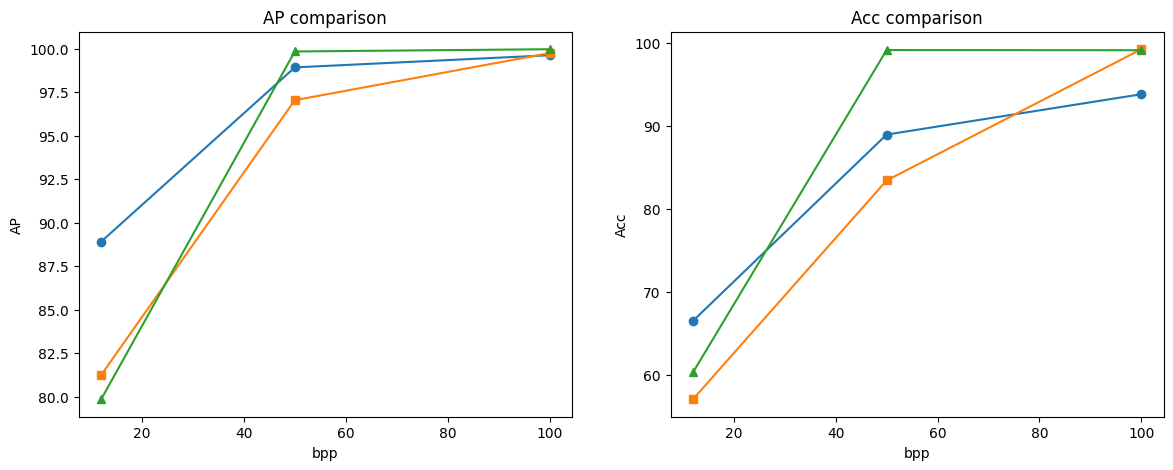

In [ ]:
def plot_results():
  markers = ["o", "s", "^"]
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
  for idx, model_name in enumerate(degradation_curve_data["detector"].unique()):
      bpp = degradation_curve_data["bpp"].unique()
      ap = degradation_curve_data[degradation_curve_data["detector"] == model_name]["ap"]
      acc = degradation_curve_data[degradation_curve_data["detector"] == model_name]["acc"]
      ax1.plot(bpp, ap, marker=markers[idx], label=model_name)
      ax2.plot(bpp, acc, marker=markers[idx], label=model_name)

      ax1.set_title("AP comparison")
      ax1.set_xlabel("bpp")
      ax1.set_ylabel("AP")
      ax2.set_title("Acc comparison")
      ax2.set_xlabel("bpp")
      ax2.set_ylabel("Acc")

  plt.show()



plot_results()

# Network

# Train

# Test